# Underwater Particle Depth Simulation

A Python simulation that models how a **microplastic particle** appears through
a camera lens as it moves from near the water surface to deeper water.

---

## Table of Contents

1. [Physics Background](#1-physics-background)
2. [System Setup](#2-system-setup)
3. [Constants](#3-constants)
4. [Code Structure](#4-code-structure)
5. [Functions Explained](#5-functions-explained)
6. [Depth Scan Loop](#6-depth-scan-loop)
7. [Output Figures](#7-output-figures)
8. [How to Run](#8-how-to-run)
9. [Tuning Parameters](#9-tuning-parameters)

---

## 1. Physics Background

### 1.1 Refraction at the Water Surface

When light travels from water into air, it bends at the interface (Snell's Law).
This makes a submerged object appear **shallower** than it really is.

For a ray at near-normal incidence, the apparent depth formula is:

$$d_{\text{apparent}} = \frac{d_{\text{real}}}{n_{\text{water}}}$$

where $n_{\text{water}} = 1.33$.

> **Example:** A particle at $d_{\text{real}} = 40\ \text{mm}$ appears at:
> $$d_{\text{apparent}} = \frac{40}{1.33} \approx 30.1\ \text{mm}$$

---

### 1.2 Thin-Lens Equation

The camera obeys the **thin-lens equation**:

$$\frac{1}{f} = \frac{1}{d_o} + \frac{1}{d_i}$$

where:
- $f$ = focal length of the camera lens
- $d_o$ = object distance (from lens to particle)
- $d_i$ = image distance (from lens to sensor)

The total object distance combines the camera-to-surface distance and the apparent depth:

$$d_o = d_{\text{camera}} + d_{\text{apparent}} = d_{\text{camera}} + \frac{d_{\text{real}}}{n_{\text{water}}}$$

---

### 1.3 Magnification

Rearranging the thin-lens equation for lateral magnification $M = d_i / d_o$:

$$\boxed{M = \frac{f}{d_o - f}} \quad \leftarrow \text{exact formula (used in this code)}$$

When $d_o \gg f$, the approximate form is valid:

$$M \approx \frac{f}{d_o} \quad \leftarrow \text{approximate (valid when } d_o \gg f \text{)}$$

---

### 1.4 Pixel Size Conversion

Once $M$ is known, the apparent image size of the particle is:

$$s_{\text{image}} = s_{\text{real}} \times M$$

Converting to pixels using the physical sensor pixel size $p$:

$$s_{\text{px}} = \frac{s_{\text{image}}}{p} = \frac{s_{\text{real}} \times M}{p}$$

---

### 1.5 Approximation Error

The percentage error between exact and approximate magnification is:

$$\varepsilon\ (\%) = \left| \frac{M_{\text{exact}} - M_{\text{approx}}}{M_{\text{exact}}} \right| \times 100$$

Since $d_o \approx 50\text{–}56\ \text{mm}$ and $f = 6\ \text{mm}$, the ratio $d_o / f \approx 9$,
keeping the error well below $1\%$ across the full depth range.

---

## 2. System Setup

```
         Camera  (lens)
              |
              |  d_camera = 50 mm  (air)
              |
    ──────────┼────────── Water surface  (n_air → n_water)
              |
              |  d_real  (water)
              |  d_apparent = d_real / n_water  (apparent position)
              |
            [●]   Particle  (diameter = 100 µm)
```

The total object distance seen by the lens:

$$d_o = 50\ \text{mm} + \frac{d_{\text{real}}}{1.33}$$

The particle sinks from $5\ \text{mm}$ to $40\ \text{mm}$ in $5\ \text{mm}$ steps.

---

## 3. Constants

| Constant | Symbol | Value | Meaning |
|---|---|---|---|
| `N_WATER` | $n_w$ | $1.33$ | Refractive index of water |
| `FOCAL_LENGTH_MM` | $f$ | $6.0\ \text{mm}$ | Camera focal length |
| `PIXEL_SIZE_UM` | $p$ | $3.45\ \mu\text{m}$ | Physical size of one sensor pixel |
| `CAMERA_DISTANCE_MM` | $d_{\text{cam}}$ | $50.0\ \text{mm}$ | Lens to water surface distance |
| `PARTICLE_SIZE_UM` | $s_{\text{real}}$ | $100.0\ \mu\text{m}$ | Real particle diameter |
| `IMAGE_SHAPE` | — | $(512,\ 512)$ | Output image size in pixels |
| `DEPTH_START_MM` | — | $5.0\ \text{mm}$ | Shallowest depth scanned |
| `DEPTH_END_MM` | — | $40.0\ \text{mm}$ | Deepest depth scanned |
| `DEPTH_STEP_MM` | — | $5.0\ \text{mm}$ | Step between depths |

---

## 4. Code Structure

```
particle_depth_simulation.py
│
├── Section 0 ── Output directory setup
├── Section 1 ── Constants
├── Section 2 ── Core functions
│   ├── apparent_depth()
│   ├── compute_magnification()
│   ├── micrometers_to_pixels()
│   └── create_particle()
├── Section 3 ── Depth scan loop (5 → 40 mm)
├── Section 4 ── Figure 1: particle image grid
├── Section 5 ── Figure 2: analysis plots (3 subplots)
├── Section 6 ── Figure 3: exact vs approximate error
└── Section 7 ── Summary printout
```

---

## 5. Functions Explained

### `apparent_depth(real_depth_mm)`

Applies the refraction formula:

$$d_{\text{apparent}} = \frac{d_{\text{real}}}{n_{\text{water}}}$$

```python
def apparent_depth(real_depth_mm):
    return real_depth_mm / N_WATER
```

---

### `compute_magnification(depth_mm, ...)`

Computes the exact thin-lens magnification at a given depth:

$$d_o = d_{\text{cam}} + \frac{d_{\text{real}}}{n_w}, \qquad M = \frac{f}{d_o - f}$$

```python
def compute_magnification(depth_mm, focal_length_mm, camera_dist_mm):
    d_o = camera_dist_mm + apparent_depth(depth_mm)
    M   = focal_length_mm / (d_o - focal_length_mm)
    return M
```

**Step-by-step for $d_{\text{real}} = 20\ \text{mm}$:**

$$d_{\text{apparent}} = \frac{20}{1.33} = 15.04\ \text{mm}$$

$$d_o = 50 + 15.04 = 65.04\ \text{mm}$$

$$M = \frac{6.0}{65.04 - 6.0} = \frac{6.0}{59.04} \approx 0.1016$$

A deeper particle gives a larger $d_o$, which gives a **smaller** $M$ — the particle appears smaller.

---

### `micrometers_to_pixels(size_um, depth_mm, ...)`

Converts real particle diameter to apparent pixel size:

$$s_{\text{px}} = \frac{s_{\text{real}} \times M}{p}$$

```python
def micrometers_to_pixels(size_um, depth_mm, ...):
    M             = compute_magnification(depth_mm, ...)
    image_size_um = size_um * M
    size_px       = image_size_um / pixel_size_um
    return size_px, M
```

**Example for $d_{\text{real}} = 5\ \text{mm}$:**

$$M = 0.1148, \quad s_{\text{image}} = 100 \times 0.1148 = 11.48\ \mu\text{m}$$

$$s_{\text{px}} = \frac{11.48}{3.45} \approx 3.33\ \text{px}$$

---

### `create_particle(center_x, center_y, size_px, image_shape)`

Generates a binary circular mask using the Euclidean distance condition:

$$\text{mask}(x, y) = \begin{cases} 1 & \text{if } \sqrt{(x - c_x)^2 + (y - c_y)^2} \leq r \\ 0 & \text{otherwise} \end{cases}$$

where $r = s_{\text{px}} / 2$ is the particle radius in pixels.

```python
def create_particle(center_x, center_y, size_px, image_shape):
    h, w   = image_shape
    y, x   = np.ogrid[:h, :w]
    radius = size_px / 2.0
    dist   = np.sqrt((x - center_x)**2 + (y - center_y)**2)
    mask   = (dist <= radius).astype(float)
    return mask
```

---

## 6. Depth Scan Loop

Iterates over:

$$d_{\text{real}} \in \{5,\ 10,\ 15,\ 20,\ 25,\ 30,\ 35,\ 40\}\ \text{mm}$$

```python
depth_range = np.arange(5.0, 40.0 + 1e-9, 5.0)

for depth_mm in depth_range:
    size_px, M = micrometers_to_pixels(PARTICLE_SIZE_UM, depth_mm)
    mask       = create_particle(cx, cy, size_px, IMAGE_SHAPE)
    results.append({ "depth_mm": depth_mm, "size_px": size_px, ... })
```

The `1e-9` offset avoids floating-point rounding excluding the last value $40.0\ \text{mm}$.

**Expected console output:**

```
Depth (mm)   App.Depth (mm)    Magnif.      Size (px)
--------------------------------------------------------
5.0          3.759             0.107051     3.102
10.0         7.519             0.105691     3.063
15.0         11.278            0.104361     3.024
20.0         15.038            0.103060     2.988
25.0         18.797            0.101787     2.951
30.0         22.556            0.100541     2.914
35.0         26.316            0.099321     2.879
40.0         30.075            0.098126     2.845
```

---

## 7. Output Figures

### Figure 1 — `particle_grid.png`

A grid of particle images at each depth. Each panel shows:
- Particle rendered with `inferno` colormap
- Dashed cyan circle marking the exact boundary at radius $r = s_{\text{px}} / 2$
- Labels: $d_{\text{real}}$, $s_{\text{px}}$, $M$

As depth increases, $d_o$ increases → $M$ decreases → particle appears smaller.

---

### Figure 2 — `depth_analysis.png`

Three side-by-side analysis plots:

| Subplot | X-axis | Y-axis | Relationship |
|---|---|---|---|
| Left | $d_{\text{real}}\ (\text{mm})$ | $d_{\text{apparent}}\ (\text{mm})$ | Linear: slope $= 1/n_w = 0.75$ |
| Middle | $d_{\text{real}}\ (\text{mm})$ | $M$ | Decreasing: $M = f/(d_o - f)$ |
| Right | $d_{\text{real}}\ (\text{mm})$ | $s_{\text{px}}\ (\text{px})$ | Decreasing: $s_{\text{px}} = s_{\text{real}} \cdot M / p$ |

---

### Figure 3 — `formula_error.png`

Compares exact vs approximate magnification:

$$M_{\text{exact}} = \frac{f}{d_o - f}, \qquad M_{\text{approx}} = \frac{f}{d_o}$$

$$\varepsilon\ (\%) = \left| \frac{M_{\text{exact}} - M_{\text{approx}}}{M_{\text{exact}}} \right| \times 100$$

Since $d_o \approx 53\text{–}80\ \text{mm} \gg f = 6\ \text{mm}$,
the error remains $< 1\%$ across the full depth range.

---

## 8. How to Run

**Option A — Jupyter Notebook:**
Paste all sections into cells and run in order.
Images appear inline and are saved to `./outputs/`.

**Option B — Script:**
```bash
python particle_depth_simulation.py
```

**Dependencies:**
```bash
pip install numpy matplotlib
```

---

## 9. Tuning Parameters

To change the simulation, edit the constants at the top of the file:

| Goal | Parameter | Example |
|---|---|---|
| Deeper/shallower scan | `DEPTH_START_MM`, `DEPTH_END_MM` | `1.0`, `100.0` |
| Finer depth steps | `DEPTH_STEP_MM` | `1.0` |
| Different particle size | `PARTICLE_SIZE_UM` | `50.0` |
| Different camera | `FOCAL_LENGTH_MM`, `PIXEL_SIZE_UM` | `12.0`, `2.4` |
| Seawater medium | `N_WATER` | `1.339` |
| Larger images | `IMAGE_SHAPE` | `(512, 512)` |
| Camera repositioned | `CAMERA_DISTANCE_MM` | `30.0` |


Outputs will be saved to: d:\software_project\Python_Project\Microplastic_Water_environment\outputs

Depth (mm)   App.Depth (mm)    Magnif.      Size (px)
--------------------------------------------------------
5.0          3.759             0.125630     3.6414
10.0         7.519             0.116462     3.3757
15.0         11.278            0.108542     3.1461
20.0         15.038            0.101630     2.9458
25.0         18.797            0.095546     2.7694
30.0         22.556            0.090149     2.6130
35.0         26.316            0.085329     2.4733
40.0         30.075            0.080999     2.3478


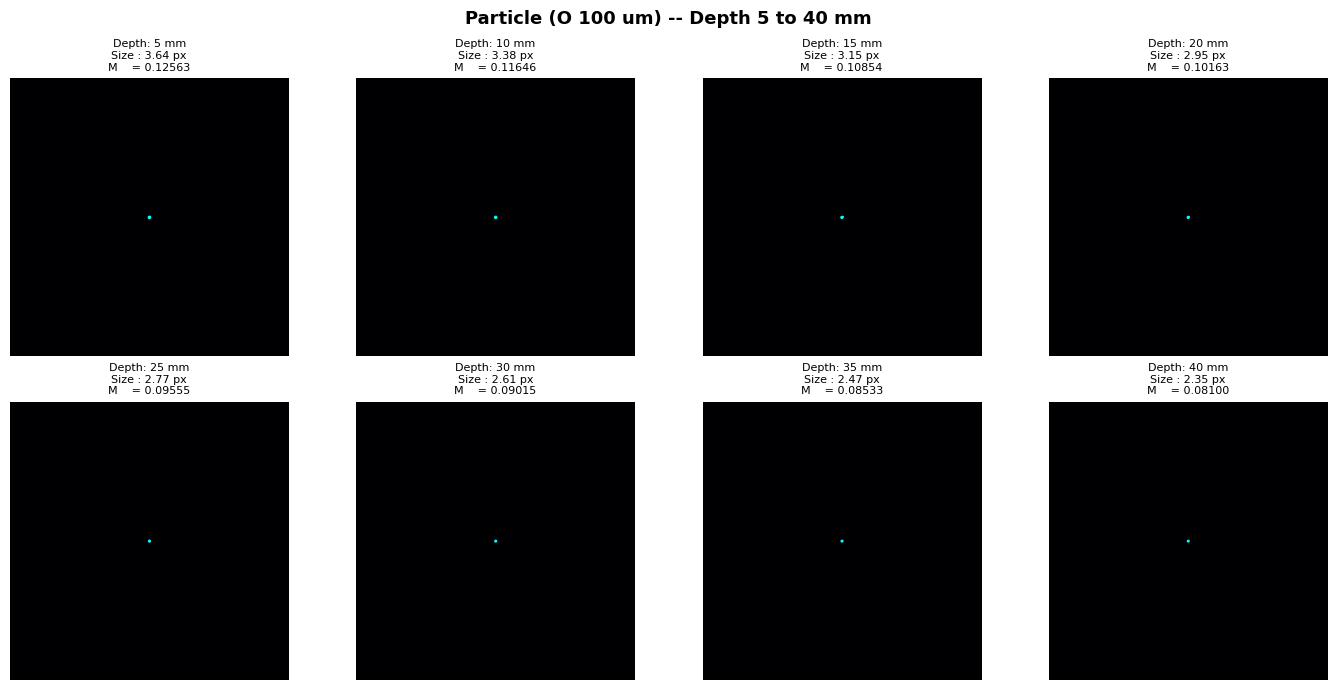

Saved: particle_grid.png


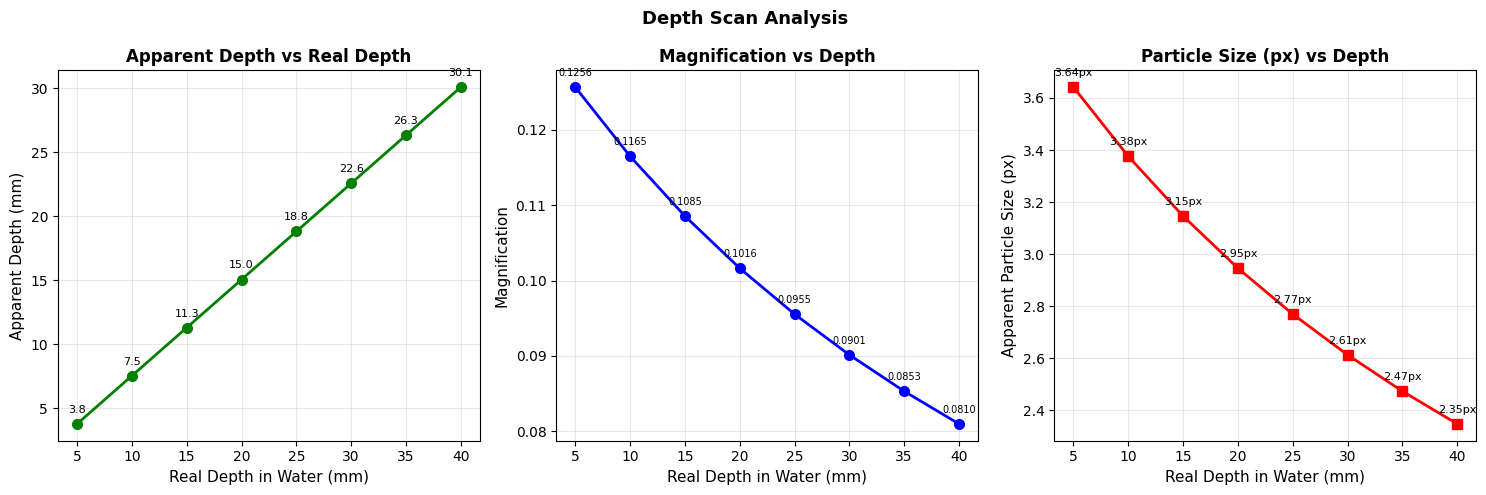

Saved: depth_analysis.png


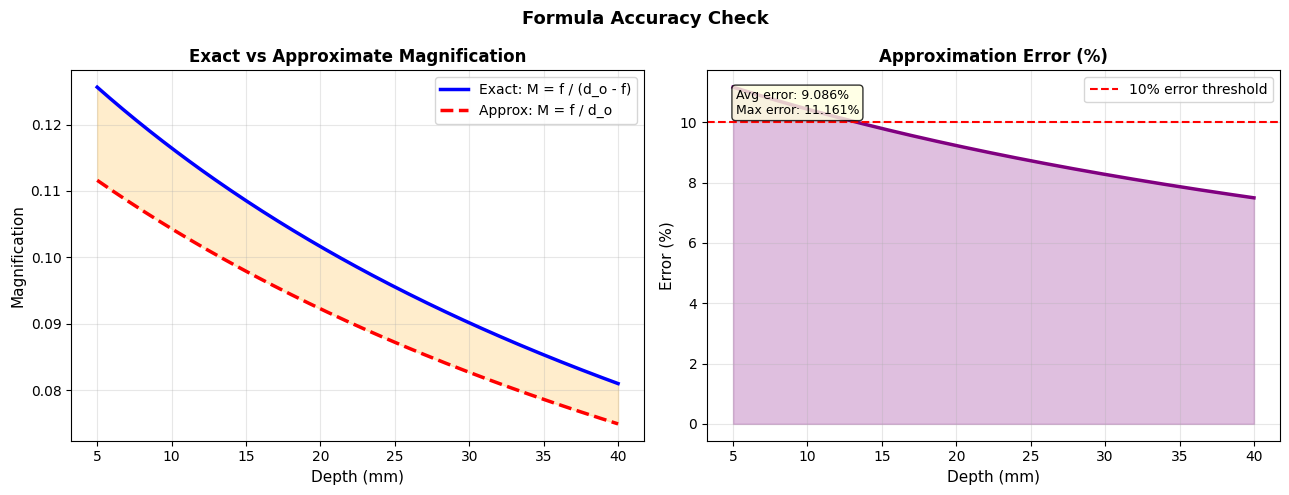

Saved: formula_error.png

SIMULATION SUMMARY
  Particle diameter   : 100.0 um
  Focal length        : 6.0 mm
  Pixel size          : 3.45 um
  Camera distance     : 50.0 mm
  Depth range         : 5.0 - 40.0 mm (step 5.0 mm)
  Refractive index    : 1.33
  Formula avg error   : 9.0858%
  Formula max error   : 11.1608%
  Output folder       : d:\software_project\Python_Project\Microplastic_Water_environment\outputs


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ===========================================================
# 0. OUTPUT DIRECTORY (works on any OS)
# ===========================================================
OUTPUT_DIR = os.path.join(os.getcwd(), "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Outputs will be saved to: {OUTPUT_DIR}")

# ===========================================================
# 1. CONSTANTS
# ===========================================================
N_WATER             = 1.33      # Refractive index of water
FOCAL_LENGTH_MM     = 6.0       # Camera focal length (mm)
PIXEL_SIZE_UM       = 3.45      # Sensor pixel size (micrometers)
CAMERA_DISTANCE_MM  = 50.0      # Distance from camera lens to water surface (mm)
PARTICLE_SIZE_UM    = 100.0     # Real particle diameter (micrometers)
IMAGE_SHAPE         = (512, 512) # (height, width) in pixels

DEPTH_START_MM      = 5.0       # Shallowest depth (mm)
DEPTH_END_MM        = 40.0      # Deepest depth (mm)
DEPTH_STEP_MM       = 5.0       # Step size (mm)

# ===========================================================
# 2. CORE FUNCTIONS
# ===========================================================

def apparent_depth(real_depth_mm):
    """
    Apply Snell's law refraction to compute apparent depth.
    Formula: apparent_depth = real_depth / n_water
    Water bends light so the particle appears shallower than it is.
    """
    return real_depth_mm / N_WATER


def compute_magnification(depth_mm,
                           focal_length_mm=FOCAL_LENGTH_MM,
                           camera_dist_mm=CAMERA_DISTANCE_MM):
    """
    Exact thin-lens magnification accounting for refraction.

    Steps:
      1. Convert real depth to apparent depth (refraction)
      2. d_o = camera_dist + apparent_depth  (total object distance)
      3. M  = f / (d_o - f)                 (thin-lens magnification)
    """
    d_o = camera_dist_mm + apparent_depth(depth_mm)
    M   = focal_length_mm / (d_o - focal_length_mm)
    return M


def micrometers_to_pixels(size_um, depth_mm,
                           focal_length_mm=FOCAL_LENGTH_MM,
                           pixel_size_um=PIXEL_SIZE_UM,
                           camera_dist_mm=CAMERA_DISTANCE_MM):
    """
    Convert real particle diameter (µm) to apparent size in pixels.

    Steps:
      1. Get magnification M at this depth
      2. image_size_um = real_size_um * M
      3. size_px = image_size_um / pixel_size_um

    Returns (size_px, M)
    """
    M             = compute_magnification(depth_mm, focal_length_mm, camera_dist_mm)
    image_size_um = size_um * M
    size_px       = image_size_um / pixel_size_um
    return size_px, M


def create_particle(center_x, center_y, size_px, image_shape):
    """
    Generate a binary circular mask representing a particle.

    Parameters
    ----------
    center_x, center_y : float  — particle centre in pixels
    size_px            : float  — particle diameter in pixels
    image_shape        : tuple  — (height, width)

    Returns
    -------
    mask : np.ndarray (float), shape = image_shape
           1.0 inside the circle, 0.0 outside
    """
    h, w   = image_shape
    y, x   = np.ogrid[:h, :w]
    radius = size_px / 2.0
    dist   = np.sqrt((x - center_x)**2 + (y - center_y)**2)
    mask   = (dist <= radius).astype(float)
    return mask

# ===========================================================
# 3. DEPTH SCAN  (5 mm to 40 mm, step 5 mm)
# ===========================================================

depth_range = np.arange(DEPTH_START_MM, DEPTH_END_MM + 1e-9, DEPTH_STEP_MM)

results = []
print(f"\n{'Depth (mm)':<12} {'App.Depth (mm)':<17} {'Magnif.':<12} {'Size (px)'}")
print("-" * 56)

for depth_mm in depth_range:
    size_px, M = micrometers_to_pixels(PARTICLE_SIZE_UM, depth_mm)
    app_d      = apparent_depth(depth_mm)

    cx   = IMAGE_SHAPE[1] // 2
    cy   = IMAGE_SHAPE[0] // 2
    mask = create_particle(cx, cy, size_px, IMAGE_SHAPE)

    results.append({
        "depth_mm"      : depth_mm,
        "apparent_mm"   : app_d,
        "magnification" : M,
        "size_px"       : size_px,
        "mask"          : mask,
    })

    print(f"{depth_mm:<12.1f} {app_d:<17.3f} {M:<12.6f} {size_px:.4f}")


# ===========================================================
# 4. FIGURE 1 — Particle Images at Each Depth
# ===========================================================

n    = len(results)
cols = 4
rows = int(np.ceil(n / cols))

fig1, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.5))
axes = axes.flatten()

for i, r in enumerate(results):
    ax = axes[i]
    ax.imshow(r["mask"], cmap="inferno", vmin=0, vmax=1)
    ax.set_title(
        f"Depth: {r['depth_mm']:.0f} mm\n"
        f"Size : {r['size_px']:.2f} px\n"
        f"M    = {r['magnification']:.5f}",
        fontsize=8
    )
    ax.axis("off")

    # Dashed cyan circle overlay showing exact particle boundary
    cx     = IMAGE_SHAPE[1] // 2
    cy     = IMAGE_SHAPE[0] // 2
    circle = plt.Circle((cx, cy), r["size_px"] / 2,
                         color="cyan", fill=False,
                         linewidth=1.2, linestyle="--")
    ax.add_patch(circle)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig1.suptitle(
    f"Particle (O {PARTICLE_SIZE_UM:.0f} um) -- Depth "
    f"{DEPTH_START_MM:.0f} to {DEPTH_END_MM:.0f} mm",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "particle_grid.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: particle_grid.png")


# ===========================================================
# 5. FIGURE 2 — Analysis Plots (3 subplots)
# ===========================================================

depths = [r["depth_mm"]      for r in results]
sizes  = [r["size_px"]       for r in results]
mags   = [r["magnification"] for r in results]
app_ds = [r["apparent_mm"]   for r in results]

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))

# --- (a) Apparent depth vs real depth ---
ax = axes2[0]
ax.plot(depths, app_ds, "go-", linewidth=2, markersize=7)
ax.set_xlabel("Real Depth in Water (mm)", fontsize=11)
ax.set_ylabel("Apparent Depth (mm)", fontsize=11)
ax.set_title("Apparent Depth vs Real Depth", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3)
for d, a in zip(depths, app_ds):
    ax.annotate(f"{a:.1f}", (d, a), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8)

# --- (b) Magnification vs depth ---
ax = axes2[1]
ax.plot(depths, mags, "bo-", linewidth=2, markersize=7)
ax.set_xlabel("Real Depth in Water (mm)", fontsize=11)
ax.set_ylabel("Magnification", fontsize=11)
ax.set_title("Magnification vs Depth", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3)
for d, m in zip(depths, mags):
    ax.annotate(f"{m:.4f}", (d, m), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=7)

# --- (c) Apparent pixel size vs depth ---
ax = axes2[2]
ax.plot(depths, sizes, "rs-", linewidth=2, markersize=7)
ax.set_xlabel("Real Depth in Water (mm)", fontsize=11)
ax.set_ylabel("Apparent Particle Size (px)", fontsize=11)
ax.set_title("Particle Size (px) vs Depth", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3)
for d, s in zip(depths, sizes):
    ax.annotate(f"{s:.2f}px", (d, s), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8)

fig2.suptitle("Depth Scan Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "depth_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: depth_analysis.png")


# ===========================================================
# 6. FIGURE 3 — Exact vs Approximate Magnification Error
# ===========================================================

depth_fine   = np.linspace(DEPTH_START_MM, DEPTH_END_MM, 200)
M_exact_arr  = []
M_approx_arr = []
error_arr    = []

for d in depth_fine:
    d_o = CAMERA_DISTANCE_MM + apparent_depth(d)
    M_e = FOCAL_LENGTH_MM / (d_o - FOCAL_LENGTH_MM)   # exact thin-lens
    M_a = FOCAL_LENGTH_MM / d_o                        # approximate (d_o >> f)
    M_exact_arr.append(M_e)
    M_approx_arr.append(M_a)
    error_arr.append(abs(M_e - M_a) / M_e * 100)

fig3, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(13, 5))

ax_l.plot(depth_fine, M_exact_arr,  "b-",  linewidth=2.5,
          label="Exact: M = f / (d_o - f)")
ax_l.plot(depth_fine, M_approx_arr, "r--", linewidth=2.5,
          label="Approx: M = f / d_o")
ax_l.fill_between(depth_fine, M_exact_arr, M_approx_arr,
                  alpha=0.2, color="orange")
ax_l.set_xlabel("Depth (mm)", fontsize=11)
ax_l.set_ylabel("Magnification", fontsize=11)
ax_l.set_title("Exact vs Approximate Magnification", fontsize=12, fontweight="bold")
ax_l.legend(fontsize=10)
ax_l.grid(True, alpha=0.3)

ax_r.plot(depth_fine, error_arr, color="purple", linewidth=2.5)
ax_r.fill_between(depth_fine, 0, error_arr, alpha=0.25, color="purple")
ax_r.axhline(10, color="red", linestyle="--", linewidth=1.5,
             label="10% error threshold")
ax_r.set_xlabel("Depth (mm)", fontsize=11)
ax_r.set_ylabel("Error (%)", fontsize=11)
ax_r.set_title("Approximation Error (%)", fontsize=12, fontweight="bold")
ax_r.legend(fontsize=10)
ax_r.grid(True, alpha=0.3)

avg_err = np.mean(error_arr)
max_err = np.max(error_arr)
ax_r.text(0.05, 0.95,
          f"Avg error: {avg_err:.3f}%\nMax error: {max_err:.3f}%",
          transform=ax_r.transAxes, fontsize=9,
          verticalalignment="top",
          bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

fig3.suptitle("Formula Accuracy Check", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "formula_error.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: formula_error.png")


# ===========================================================
# 7. SUMMARY
# ===========================================================
print("\n" + "="*56)
print("SIMULATION SUMMARY")
print("="*56)
print(f"  Particle diameter   : {PARTICLE_SIZE_UM} um")
print(f"  Focal length        : {FOCAL_LENGTH_MM} mm")
print(f"  Pixel size          : {PIXEL_SIZE_UM} um")
print(f"  Camera distance     : {CAMERA_DISTANCE_MM} mm")
print(f"  Depth range         : {DEPTH_START_MM} - {DEPTH_END_MM} mm "
      f"(step {DEPTH_STEP_MM} mm)")
print(f"  Refractive index    : {N_WATER}")
print(f"  Formula avg error   : {avg_err:.4f}%")
print(f"  Formula max error   : {max_err:.4f}%")
print(f"  Output folder       : {OUTPUT_DIR}")
print("="*56)